**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of multiple fluorophores](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [PFA data](#toc1_1_1_)    
      - [2 fluorophores](#toc1_1_1_1_)    
      - [3 Fluorophores](#toc1_1_1_2_)    
      - [4 fluorophores](#toc1_1_1_3_)    
  - [Figure](#toc1_2_)    
    - [Preparation](#toc1_2_1_)    
    - [Figure](#toc1_2_2_)    
    - [Figure with locs](#toc1_2_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of multiple fluorophores](#toc0_)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.miscellaneous as mi
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

reading_from_1 = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_15_comprehensive_photophys_model"

## <a id='toc1_1_'></a>[Reading data](#toc0_)

### <a id='toc1_1_1_'></a>[PFA data](#toc0_)

#### <a id='toc1_1_1_3_'></a>[4 fluorophores](#toc0_)

In [2]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_4f_all = []
fingerprints_4f_all_truncated = []
OFF_periods_4f_1ms_all = []
ON_periods_4f_1ms_all = []
number_ON_periods_4f_1ms_all = []
intensities_4f_1ms_all = []
OFF_periods_4f_5ms_all = []
ON_periods_4f_5ms_all = []
number_ON_periods_4f_5ms_all = []
intensities_4f_5ms_all = []
parameters_4f_all = []
locs_4f_all = []
locs_4f_all_truncated = []
emis_collection = []
for i, id in enumerate(identifiers):
    fingerprints_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    locs_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_4f_1ms_all.append([])
    ON_periods_4f_1ms_all.append([])
    intensities_4f_1ms_all.append([])
    number_ON_periods_4f_1ms_all.append([])
    OFF_periods_4f_5ms_all.append([])
    ON_periods_4f_5ms_all.append([])
    intensities_4f_5ms_all.append([])
    number_ON_periods_4f_5ms_all.append([])
    emis_collection.append([])
    u = 0
    for file in Path(reading_from_1).iterdir():
        if file.suffix == ".parquet" and id in file.name:
            data_5ms = pd.read_parquet(file)
            data_1ms = data_5ms.copy()
            data_5ms = data_5ms.groupby(data_5ms.index // 0.005).sum()
            data_5ms.index = data_5ms.index * 0.005
            non_zero = data_1ms[data_1ms > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            fingerprints_4f_all[i] += data_1ms.sum(axis=1)
            locs_4f_all[i] += (data_1ms > 0).sum(axis=1)
            intensities_4f_1ms_all[i] += non_zero.tolist()
            non_zero = data_5ms[data_5ms > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            intensities_4f_5ms_all[i] += non_zero.tolist()
            for col in data_1ms.columns:
                emis_1ms = em.Emissions()
                emis_1ms.event_time_series = data_1ms[col]
                emis_5ms = em.Emissions()
                emis_5ms.event_time_series = data_5ms[col]
                if u < 10:
                    emis_collection[i].append(emis_1ms)
                blinks = bl.Blinking(emis_1ms)
                OFF_periods_4f_1ms_all[i] += blinks.off_periods.tolist()
                ON_periods_4f_1ms_all[i] += blinks.on_periods.tolist()
                number_ON_periods_4f_1ms_all[i].append(blinks.on_periods.size)
                blinks = bl.Blinking(emis_5ms)
                OFF_periods_4f_5ms_all[i] += blinks.off_periods.tolist()
                ON_periods_4f_5ms_all[i] += blinks.on_periods.tolist()
                number_ON_periods_4f_5ms_all[i].append(blinks.on_periods.size)
            u += 1

    fingerprint = fingerprints_4f_all[i].cumsum() / fingerprints_4f_all[i].sum()
    fingerprints_4f_all[i] = fingerprint
    loc_fingerprint = locs_4f_all[i].cumsum() / locs_4f_all[i].sum()
    locs_4f_all[i] = loc_fingerprint
    fingerprint_truncated = rt.truncate_fingerprints(
        fingerprint,
        low=3000,
    )
    fingerprints_4f_all_truncated.append(fingerprint_truncated)
    locs_4f_truncated = rt.truncate_fingerprints(
        loc_fingerprint,
        low=3000,
    )
    locs_4f_all_truncated.append(locs_4f_truncated)

## <a id='toc1_2_'></a>[Figure](#toc0_)

### <a id='toc1_2_1_'></a>[Preparation](#toc0_)

In [3]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


OFF_periods_4f_1ms_all = [
    np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_4f_1ms_all
]
log_bins_OFF_4f_1ms = get_log_bins(OFF_periods_4f_1ms_all)
weights_OFF_4f_1ms = [
    np.ones_like(OFF_periods) / OFF_periods.size
    for OFF_periods in OFF_periods_4f_1ms_all
]
ON_periods_4f_1ms_all = [
    np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_4f_1ms_all
]
log_bins_ON_4f_1ms = get_log_bins(ON_periods_4f_1ms_all)
weights_ON_4f_1ms = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_4f_1ms_all
]
intensities_4f_1ms_all = [
    np.array(intensities) for intensities in intensities_4f_1ms_all
]
weights_intensities_4f_1ms = [
    np.ones_like(intensities) / len(intensities)
    for intensities in intensities_4f_1ms_all
]

number_ON_periods_4f_1ms_all = [
    np.array(number_ON_periods) for number_ON_periods in number_ON_periods_4f_1ms_all
]
weights_number_ON_periods_1ms = [
    np.ones_like(number_ON_periods) / number_ON_periods.size
    for number_ON_periods in number_ON_periods_4f_1ms_all
]

In [4]:
print("OFF periods (s)")
for i, off_periods in enumerate(OFF_periods_4f_1ms_all):
    print(f"{identifiers[i]}: {np.mean(off_periods)}")
print()
print("ON periods (s)")
for i, on_periods in enumerate(ON_periods_4f_1ms_all):
    print(f"{identifiers[i]}: {np.mean(on_periods)}")
print()
print("Intensities (photons / ms)")
for i, intensities in enumerate(intensities_4f_1ms_all):
    print(f"{identifiers[i]}: {np.mean(intensities)}")

OFF periods (s)
3nm: 0.07585330723238878
6nm: 0.11136102028683958
9nm: 0.13013412447791778
18nm: 0.13968570658601945

ON periods (s)
3nm: 0.02414780821448049
6nm: 0.01465860633666624
9nm: 0.00480497966750641
18nm: 0.003979918891416258

Intensities (photons / ms)
3nm: 106.04863105076561
6nm: 120.52888126593686
9nm: 70.13448719506215
18nm: 60.96035475838026


In [5]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


OFF_periods_4f_5ms_all = [
    np.array(OFF_periods) * 5e-3 for OFF_periods in OFF_periods_4f_5ms_all
]
log_bins_OFF_4f_5ms = get_log_bins(OFF_periods_4f_5ms_all)
weights_OFF_4f_5ms = [
    np.ones_like(OFF_periods) / OFF_periods.size
    for OFF_periods in OFF_periods_4f_5ms_all
]
ON_periods_4f_5ms_all = [
    np.array(ON_periods) * 5e-3 for ON_periods in ON_periods_4f_5ms_all
]
log_bins_ON_4f_5ms = get_log_bins(ON_periods_4f_5ms_all)
weights_ON_4f_5ms = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_4f_5ms_all
]
intensities_4f_5ms_all = [
    np.array(intensities) for intensities in intensities_4f_5ms_all
]
weights_intensities_4f_5ms = [
    np.ones_like(intensities) / len(intensities)
    for intensities in intensities_4f_5ms_all
]

number_ON_periods_4f_5ms_all = [
    np.array(number_ON_periods) for number_ON_periods in number_ON_periods_4f_5ms_all
]
weights_number_ON_periods_5ms = [
    np.ones_like(number_ON_periods) / number_ON_periods.size
    for number_ON_periods in number_ON_periods_4f_5ms_all
]

In [6]:
print("OFF periods (s)")
for i, off_periods in enumerate(OFF_periods_4f_5ms_all):
    print(f"{identifiers[i]}: {np.mean(off_periods)}")
print()
print("ON periods (s)")
for i, on_periods in enumerate(ON_periods_4f_5ms_all):
    print(f"{identifiers[i]}: {np.mean(on_periods)}")
print()
print("Intensities (photons / ms)")
for i, intensities in enumerate(intensities_4f_5ms_all):
    print(f"{identifiers[i]}: {np.mean(intensities)}")

OFF periods (s)
3nm: 10.722122416534182
6nm: 5.213548782789205
9nm: 3.7633490527182865
18nm: 3.704201702606112

ON periods (s)
3nm: 3.469037530266344
6nm: 0.7458224800938213
9nm: 0.18354525862068966
18nm: 0.14727141100400654

Intensities (photons / ms)
3nm: 504.695175266003
6nm: 550.7304077425522
9nm: 265.1376705499319
18nm: 218.21711486177287


### <a id='toc1_2_2_'></a>[Figure](#toc0_)

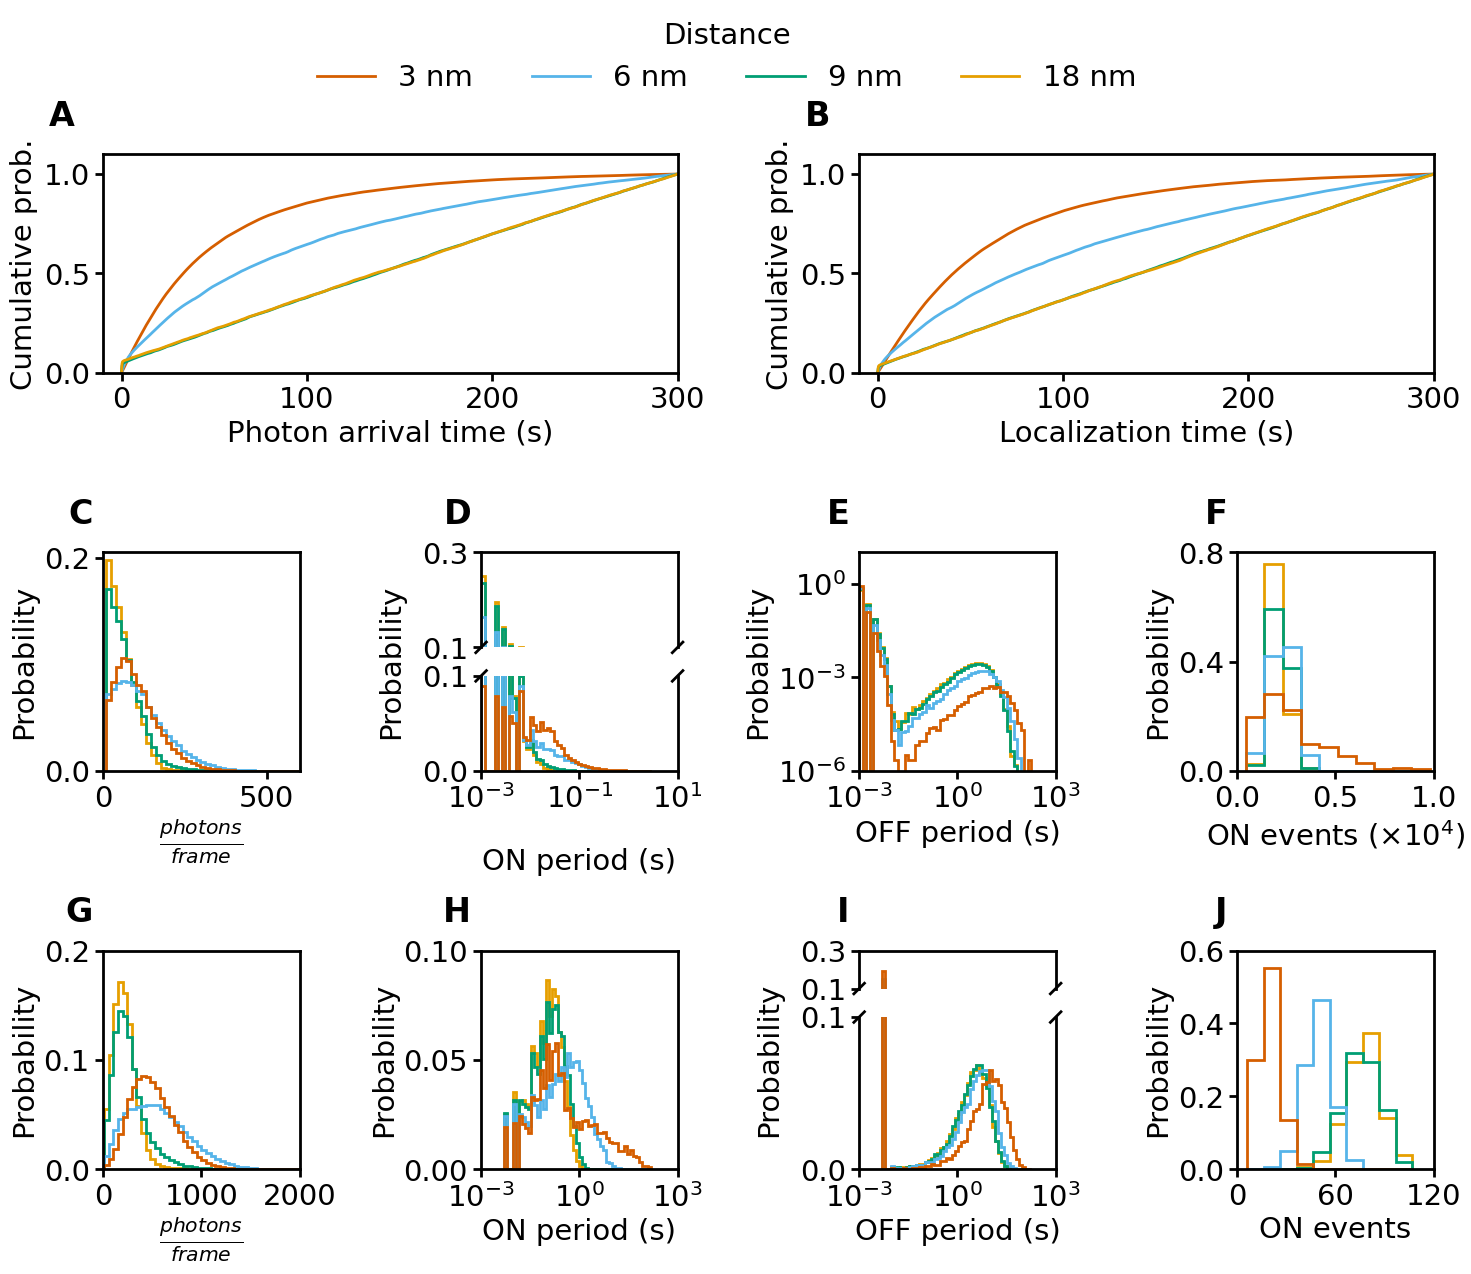

In [7]:
from matplotlib.lines import Line2D

red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(15, 12))


labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
legendtitle1 = "Distance"

ax0 = fig.add_subplot(gs[0, 0:2])
for fingerprint, label, color in zip(fingerprints_4f_all, labels1, colors):
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        axes=ax0,
        xlim=[-10, 300],
        ylim=[0, 1.1],
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        lw=2,
        marker=None,
        linestyle="-",
        label=label,
        color=color,
    )

ax1 = fig.add_subplot(gs[0, 2:])
for fingerprint, label, color in zip(locs_4f_all, labels1, colors):
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        label=label,
        color=color,
        marker=None,
        linestyle="-",
        lw=2,
        ylabel="Cumulative prob.",
        xlabel="Localization time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
        axes=ax1,
    )


ax2 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    type_="hist",
    data=intensities_4f_1ms_all,
    axes=ax2,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=50,
    weights=weights_intensities_4f_1ms,
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.205],
    yticks=[0, 0.2],
    xlim=[0, 600],
)
bax3 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[1, 1],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 1),
)
bax3.hist(
    ON_periods_4f_1ms_all,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=log_bins_ON_4f_1ms,
    weights=weights_ON_4f_1ms,
)
bax3.set_xscale("log")
bax3.set_ylabel(
    "Probability",
    fontsize=21,
    labelpad=55,
)
bax3.set_xlabel("ON period (s)", fontsize=21, labelpad=55)
bax3.tick_params(labelsize=21, width=2, length=6)
bax3.set_xlim([1e-3, 1e1])
bax3.axs[1].set_xticks([1e-3, 1e-1, 1e1])
bax3.axs[0].set_yticks([0.1, 0.3])
bax3.axs[1].set_yticks([0, 0.1])

ax4 = fig.add_subplot(gs[1, 2])
fi.universal_figure(
    type_="hist",
    data=OFF_periods_4f_1ms_all,
    axes=ax4,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=log_bins_OFF_4f_1ms,
    weights=weights_OFF_4f_1ms,
    xscale="log",
    yscale="log",
    ylabel="Probability",
    xlabel="OFF period (s)",
    xlim=[1e-3, 1e3],
    ylim=[1e-6, 1e1],
)

ax5 = fig.add_subplot(gs[1, 3])
fi.universal_figure(
    type_="hist",
    data=number_ON_periods_4f_1ms_all,
    axes=ax5,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 10000],
    ylim=[0, 0.8],
    yticks=[0, 0.4, 0.8],
    xticks=[0, 5000, 10000],
    tick_style_x="sci",
    weights=weights_number_ON_periods_1ms,
)

ax6 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    type_="hist",
    data=intensities_4f_5ms_all,
    axes=ax6,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=50,
    weights=weights_intensities_4f_5ms,
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.2],
    xlim=[0, 2000],
)
ax7 = fig.add_subplot(gs[2, 1])
fi.universal_figure(
    type_="hist",
    data=ON_periods_4f_5ms_all,
    axes=ax7,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=log_bins_ON_4f_5ms,
    weights=weights_ON_4f_5ms,
    xscale="log",
    ylabel="Probability",
    xlabel="ON period (s)",
    ylim=[0, 0.1],
    xlim=[1e-3, 1e3],
)

bax8 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 2],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax8.hist(
    OFF_periods_4f_5ms_all,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    color=colors,
    alpha=1,
    bins=log_bins_OFF_4f_5ms,
    weights=weights_OFF_4f_5ms,
)
bax8.set_xscale("log")
bax8.set_ylabel("Probability", fontsize=21, labelpad=55)
bax8.set_xlabel("OFF period (s)", fontsize=21, labelpad=35)
bax8.tick_params(labelsize=21, width=2, length=6)
bax8.set_xlim([1e-3, 1e3])
bax8.set_xticks([1e-3, 1e0, 1e3])
bax8.axs[0].set_yticks([0.1, 0.3])
bax8.axs[1].set_yticks([0, 0.1])

ax9 = fig.add_subplot(gs[2, 3])
fi.universal_figure(
    type_="hist",
    data=number_ON_periods_4f_5ms_all,
    axes=ax9,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 120],
    ylim=[0, 0.6],
    xticks=[0, 60, 120],
    weights=weights_number_ON_periods_5ms,
)


letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
axes = fig.get_axes()
j = 0
for i, axis in enumerate(axes):
    # if i in [3, 4, 6, 7, 12, 13]:
    if i in [3, 4, 10, 11]:
        continue
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]

fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.07),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
fig.tight_layout()
for handle in bax3.diag_handles:
    handle.remove()
bax3.draw_diags()
for handle in bax8.diag_handles:
    handle.remove()
bax8.draw_diags()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)

fig.savefig(
    reading_from_1 + r"\figures\compr_photophys_model.png",
    bbox_inches=bbox,
    dpi=300,
)

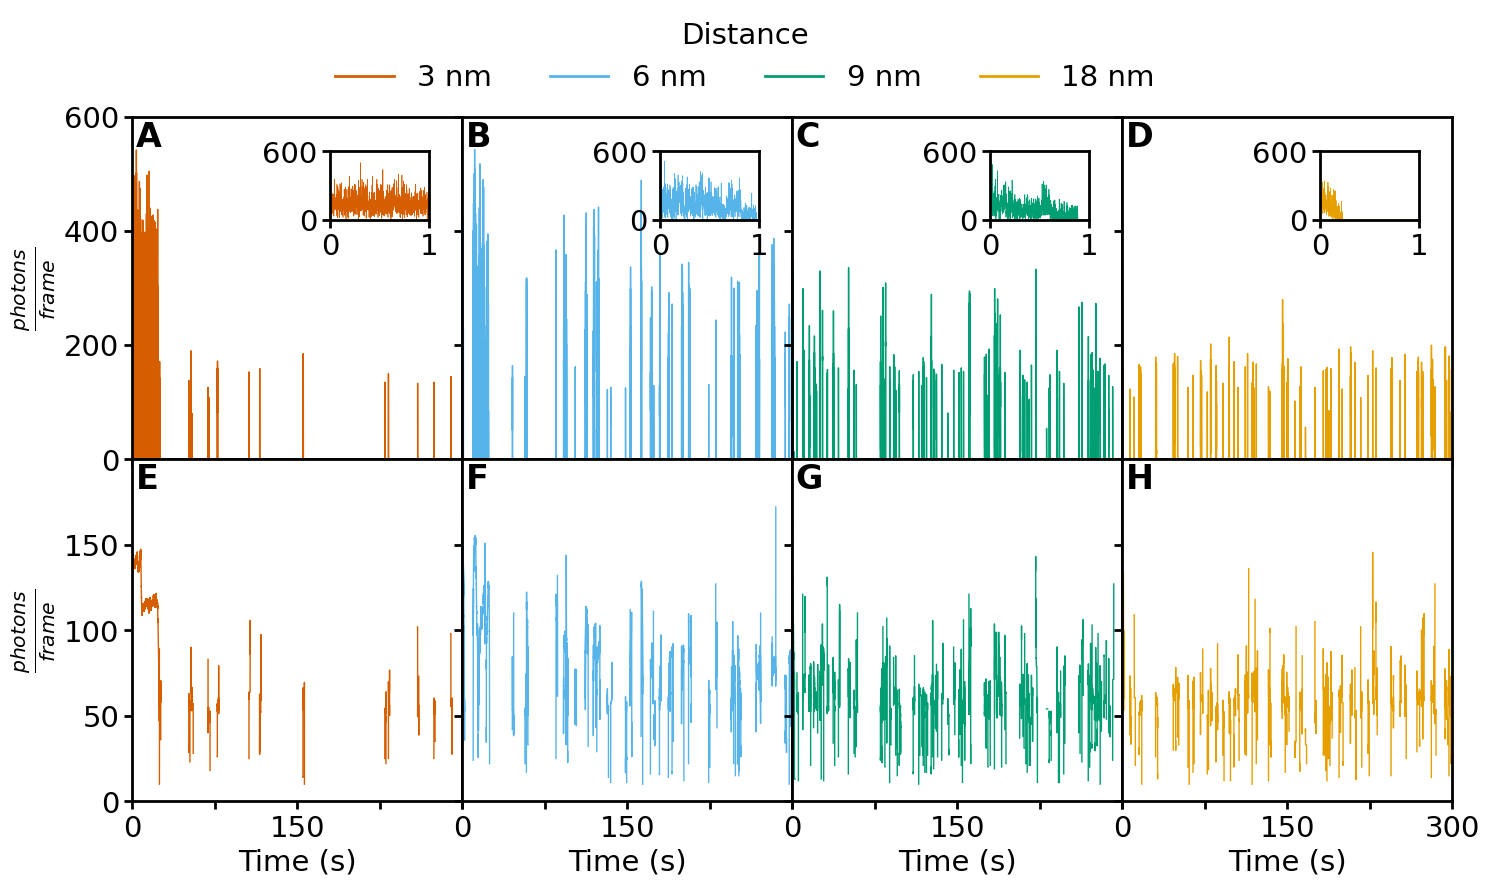

In [8]:
def add_inset(ax, emis, color):
    inset = ax.inset_axes([0.6, 0.7, 0.3, 0.2], xlim=(0, 1), ylim=(0, 600))
    emis.plot_time_series(axes=inset, color=color, lw=0.5)
    inset.set_xlabel("")
    inset.set_ylabel("")
    inset.set_yticks([0, 600])


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(
    2,
    4,
    hspace=0,
    wspace=0,
)
fig = plt.figure(figsize=(15, 8))

for i, emis in enumerate(emis_collection):
    ax = fig.add_subplot(gs[0, i])
    emis[7].plot_time_series(
        axes=ax,
        lw=1,
        color=colors[i],
        ylim=[0, 600],
        yticks=[0, 200, 400, 600],
        xlim=[0, 300],
        xticks=[0, 150, 300],
    )
    add_inset(ax, emis[7], colors[i])


for i, emis in enumerate(emis_collection):
    emis2 = em.Emissions()
    emis2.event_time_series = emis[7].event_time_series.replace(0, np.nan)
    emis2.event_time_series = emis2.event_time_series.rolling(
        1000, min_periods=1
    ).mean()
    ax = fig.add_subplot(gs[1, i])
    if i != 3:
        xticklabels = dict(labels=["0", "", "150", "", ""])
    else:
        xticklabels = dict(labels=["0", "", "150", "", "300"])
    emis2.plot_time_series(
        axes=ax,
        lw=1,
        color=colors[i],
        ylim=[0, 200],
        yticks=[0, 50, 100, 150],
        xlim=[0, 300],
        xticks=[0, 75, 150, 225, 300],
        xticklabels=xticklabels,
    )

letters = ["A", "B", "C", "D", "E", "F", "G", "H"]
axes = fig.get_axes()
for i, axis in enumerate(axes):
    axis.text(
        0.01,
        0.99,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="left",
    )
    axis.label_outer()

custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]

fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.12),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
fig.tight_layout()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)

fig.savefig(
    reading_from_1 + r"\figures\compr_photophys_model_2.png",
    bbox_inches=bbox,
    dpi=300,
)